In [1]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5080


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import csv

torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
LATENT_DIM = 128
IMG_SIZE = 64
BATCH_SIZE = 64
N_CRITIC = 5
GP_LAMBDA = 10
LR = 1e-4
BETAS = (0.0, 0.9)
N_EPOCHS_UNCOND = 30
N_EPOCHS_COND = 30
MAX_IMAGES = 50000
NUM_WORKERS = 0

print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5080


In [5]:
import kagglehub
path = kagglehub.dataset_download('jessicali9530/celeba-dataset')
DATASET_PATH = Path(path)
print('Path to dataset files:', path)
for item in sorted(DATASET_PATH.iterdir()):
    print(' ', item.name)

Path to dataset files: C:\Users\Pavel\.cache\kagglehub\datasets\jessicali9530\celeba-dataset\versions\2
  img_align_celeba
  list_attr_celeba.csv
  list_bbox_celeba.csv
  list_eval_partition.csv
  list_landmarks_align_celeba.csv


In [6]:
attr_csv = next(DATASET_PATH.rglob('list_attr_celeba.csv'), None)
if attr_csv:
    attrs = pd.read_csv(attr_csv)
else:
    attr_txt = next(DATASET_PATH.rglob('list_attr_celeba.txt'))
    with open(attr_txt) as f:
        _ = f.readline()
        col_names = f.readline().split()
    attrs = pd.read_csv(attr_txt, sep='\\s+', skiprows=2, header=None,
                        names=['image_id'] + col_names)

print('Attributes:', len(attrs), 'rows')
print('Columns (first 10):', attrs.columns.tolist()[:10])
n_male = (attrs['Male'] == 1).sum()
n_female = (attrs['Male'] == -1).sum()
print(f'Male: {n_male}, Female: {n_female}')
attrs['gender'] = (attrs['Male'] == 1).astype(int)

Attributes: 202599 rows
Columns (first 10): ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair']
Male: 84434, Female: 118165


Total: 50000, To process: 0
Faces saved: 50000


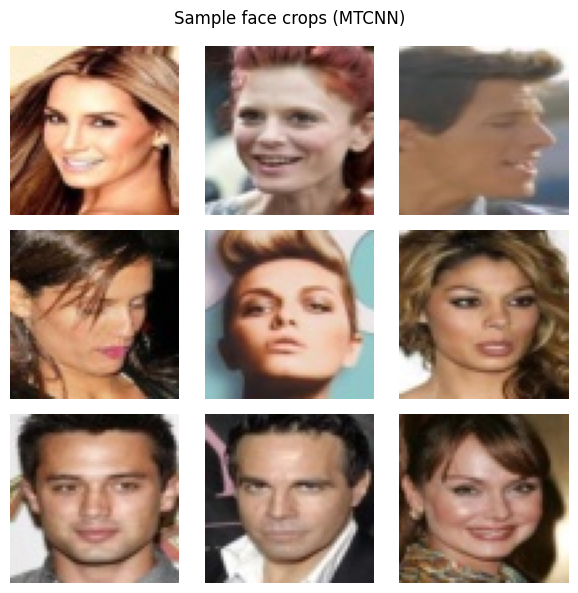

In [7]:
from facenet_pytorch import MTCNN
from PIL import Image
from tqdm import tqdm

FACES_DIR = Path('celeba_faces')
FACES_DIR.mkdir(exist_ok=True)

img_dir = None
for candidate in [
    DATASET_PATH / 'img_align_celeba' / 'img_align_celeba',
    DATASET_PATH / 'img_align_celeba',
]:
    if candidate.is_dir() and any(candidate.glob('*.jpg')):
        img_dir = candidate
        break
assert img_dir is not None, 'Image directory not found'

all_images = sorted(img_dir.glob('*.jpg'))[:MAX_IMAGES]
done_names = {f.name for f in FACES_DIR.glob('*.jpg')}
to_process = [f for f in all_images if f.name not in done_names]
print(f'Total: {len(all_images)}, To process: {len(to_process)}')

if to_process:
    try:
        RESAMPLE = Image.Resampling.BICUBIC
    except AttributeError:
        RESAMPLE = Image.BICUBIC

    mtcnn = MTCNN(image_size=IMG_SIZE, margin=20, min_face_size=20,
                  keep_all=False, post_process=False, device=DEVICE)
    BDET = 32

    for i in tqdm(range(0, len(to_process), BDET), desc='Face detection'):
        batch = to_process[i:i + BDET]
        imgs = [Image.open(f).convert('RGB') for f in batch]
        try:
            results = mtcnn(imgs)
            if isinstance(results, torch.Tensor):
                results = [results[j] for j in range(results.shape[0])]
            elif results is None:
                results = [None] * len(imgs)
        except Exception:
            results = [None] * len(imgs)
        for img, f, face in zip(imgs, batch, results):
            out_path = FACES_DIR / f.name
            if face is not None:
                arr = face.clamp(0, 255).byte().permute(1, 2, 0).cpu().numpy()
                pil = Image.fromarray(arr)
            else:
                pil = img.resize((IMG_SIZE, IMG_SIZE), RESAMPLE)
            pil.save(out_path, quality=95)

    del mtcnn
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

n_saved = len(list(FACES_DIR.glob('*.jpg')))
print(f'Faces saved: {n_saved}')

sample_files = sorted(FACES_DIR.glob('*.jpg'))[:9]
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for ax, fp in zip(axes.flat, sample_files):
    ax.imshow(Image.open(fp))
    ax.axis('off')
plt.suptitle('Sample face crops (MTCNN)')
plt.tight_layout()
plt.show()

In [8]:
class FaceDataset(Dataset):
    def __init__(self, faces_dir, attrs_df, augment=True):
        self.faces_dir = Path(faces_dir)
        tf = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
        if augment:
            tf.append(transforms.RandomHorizontalFlip())
        tf += [
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]
        self.transform = transforms.Compose(tf)
        img_id_col = attrs_df.columns[0]
        face_files = {f.name for f in self.faces_dir.glob('*.jpg')}
        df = attrs_df[attrs_df[img_id_col].isin(face_files)]
        self.files = df[img_id_col].tolist()
        self.labels = df['gender'].tolist()

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.faces_dir / self.files[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]


dataset = FaceDataset(FACES_DIR, attrs)
loader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'), drop_last=True
)
male_count = sum(dataset.labels)
print(f'Dataset: {len(dataset)} | Male: {male_count} | Female: {len(dataset) - male_count}')

Dataset: 50000 | Male: 20945 | Female: 29055


In [ ]:
def gen_block(ic, oc):
    return nn.Sequential(
        nn.ConvTranspose2d(ic, oc, 4, 2, 1, bias=False),
        nn.BatchNorm2d(oc),
        nn.ReLU(inplace=True)
    )


def crit_block(ic, oc, norm=True):
    layers = [nn.Conv2d(ic, oc, 4, 2, 1, bias=False)]
    if norm:
        layers.append(nn.InstanceNorm2d(oc, affine=True))
    layers.append(nn.LeakyReLU(0.2, inplace=True))
    return nn.Sequential(*layers)


def _init_w(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)


class Generator(nn.Module):
    def __init__(self, z_dim=LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(z_dim, 512 * 4 * 4)
        self.net = nn.Sequential(
            gen_block(512, 256),
            gen_block(256, 128),
            gen_block(128, 64),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
        self.apply(_init_w)

    def forward(self, z):
        return self.net(self.fc(z).view(-1, 512, 4, 4))


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            crit_block(3, 64, norm=False),
            crit_block(64, 128),
            crit_block(128, 256),
            crit_block(256, 512)
        )
        self.fc = nn.Linear(512 * 4 * 4, 1)
        self.apply(_init_w)

    def forward(self, x):
        return self.fc(self.net(x).view(x.size(0), -1))


class CondGenerator(nn.Module):
    def __init__(self, z_dim=LATENT_DIM, n_cls=2, emb_dim=64):
        super().__init__()
        self.emb = nn.Embedding(n_cls, emb_dim)
        self.fc = nn.Linear(z_dim + emb_dim, 512 * 4 * 4)
        self.net = nn.Sequential(
            gen_block(512, 256),
            gen_block(256, 128),
            gen_block(128, 64),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
        self.apply(_init_w)

    def forward(self, z, labels):
        x = torch.cat([z, self.emb(labels)], dim=1)
        return self.net(self.fc(x).view(-1, 512, 4, 4))


class CondCritic(nn.Module):
    def __init__(self, n_cls=2):
        super().__init__()
        self.net = nn.Sequential(
            crit_block(3, 64, norm=False),
            crit_block(64, 128),
            crit_block(128, 256),
            crit_block(256, 512)
        )
        self.feat_fc = nn.Linear(512 * 4 * 4, 512)
        self.fc = nn.Linear(512, 1)
        self.proj = nn.Embedding(n_cls, 512)
        self.apply(_init_w)

    def forward(self, x, labels):
        h = F.leaky_relu(self.feat_fc(self.net(x).view(x.size(0), -1)), 0.2)
        return self.fc(h) + (h * self.proj(labels)).sum(1, keepdim=True)


_g = Generator().to(DEVICE)
_c = Critic().to(DEVICE)
print(f'Generator:     {sum(p.numel() for p in _g.parameters()):,} params')
print(f'Critic:        {sum(p.numel() for p in _c.parameters()):,} params')
del _g, _c

Generator:     3,813,248 params
Critic:        2,765,569 params


In [10]:
def compute_gp(critic, real, fake, device, labels=None):
    B = real.size(0)
    alpha = torch.rand(B, 1, 1, 1, device=device)
    interp = (alpha * real.detach() + (1 - alpha) * fake.detach()).requires_grad_(True)
    d_out = critic(interp, labels) if labels is not None else critic(interp)
    grads = torch.autograd.grad(
        d_out, interp,
        grad_outputs=torch.ones_like(d_out),
        create_graph=True, only_inputs=True
    )[0]
    return ((grads.view(B, -1).norm(2, dim=1) - 1) ** 2).mean()


def train_wgangp(gen, critic, loader, n_epochs, device,
                 log_path, save_path, conditional=False):
    opt_G = torch.optim.Adam(gen.parameters(), lr=LR, betas=BETAS)
    opt_C = torch.optim.Adam(critic.parameters(), lr=LR, betas=BETAS)
    log_f = open(log_path, 'w', newline='')
    logger = csv.writer(log_f)
    logger.writerow(['epoch', 'step', 'd_loss', 'g_loss', 'gp'])
    gen.train()
    critic.train()
    global_step = 0

    for epoch in range(1, n_epochs + 1):
        ep_d, ep_g, ep_gp = [], [], []

        for step, (real, labels) in enumerate(loader):
            real = real.to(device)
            labels = labels.to(device)
            B = real.size(0)

            with torch.no_grad():
                z = torch.randn(B, LATENT_DIM, device=device)
                fake = gen(z, labels) if conditional else gen(z)

            if conditional:
                d_real = critic(real, labels).mean()
                d_fake = critic(fake, labels).mean()
                gp = compute_gp(critic, real, fake, device, labels)
            else:
                d_real = critic(real).mean()
                d_fake = critic(fake).mean()
                gp = compute_gp(critic, real, fake, device)

            d_loss = d_fake - d_real + GP_LAMBDA * gp
            opt_C.zero_grad()
            d_loss.backward()
            opt_C.step()
            ep_d.append(d_loss.item())
            ep_gp.append(gp.item())

            if (step + 1) % N_CRITIC == 0:
                z = torch.randn(B, LATENT_DIM, device=device)
                if conditional:
                    lbl_g = torch.randint(0, 2, (B,), device=device)
                    g_loss = -critic(gen(z, lbl_g), lbl_g).mean()
                else:
                    g_loss = -critic(gen(z)).mean()
                opt_G.zero_grad()
                g_loss.backward()
                opt_G.step()
                ep_g.append(g_loss.item())
                logger.writerow([epoch, global_step,
                                  round(d_loss.item(), 4),
                                  round(g_loss.item(), 4),
                                  round(gp.item(), 4)])
                log_f.flush()

            global_step += 1

        avg_g = np.mean(ep_g) if ep_g else 0.0
        print(f'Epoch {epoch}/{n_epochs} | '
              f'D={np.mean(ep_d):.3f} G={avg_g:.3f} GP={np.mean(ep_gp):.3f}')

        if epoch % 5 == 0 or epoch == n_epochs:
            gen.eval()
            with torch.no_grad():
                z_s = torch.randn(16, LATENT_DIM, device=device)
                if conditional:
                    lbl_s = torch.randint(0, 2, (16,), device=device)
                    s = gen(z_s, lbl_s)
                else:
                    s = gen(z_s)
            tag = save_path.replace('.pth', '')
            save_image((s * 0.5 + 0.5).clamp(0, 1), f'{tag}_ep{epoch}.png', nrow=4)
            gen.train()

    log_f.close()
    torch.save(gen.state_dict(), save_path)
    return gen

In [11]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore


def compute_metrics(gen, loader, device, n_samples=5000,
                    conditional=False, label=None):
    fid = FrechetInceptionDistance(feature=2048).to(device)
    isc = InceptionScore().to(device)
    gen.eval()

    real_count = 0
    for real, _ in loader:
        real_u8 = ((real * 0.5 + 0.5).clamp(0, 1) * 255).to(torch.uint8).to(device)
        fid.update(real_u8, real=True)
        real_count += real.size(0)
        if real_count >= n_samples:
            break

    fake_count = 0
    while fake_count < n_samples:
        B = min(BATCH_SIZE, n_samples - fake_count)
        z = torch.randn(B, LATENT_DIM, device=device)
        with torch.no_grad():
            if conditional:
                lbl = torch.full((B,), label, dtype=torch.long, device=device)
                fake = gen(z, lbl)
            else:
                fake = gen(z)
        fake_u8 = ((fake * 0.5 + 0.5).clamp(0, 1) * 255).to(torch.uint8)
        fid.update(fake_u8, real=False)
        isc.update(fake_u8)
        fake_count += B

    fid_score = fid.compute().item()
    is_mean, is_std = isc.compute()
    gen.train()
    return fid_score, is_mean.item(), is_std.item()

In [12]:
gen_u = Generator().to(DEVICE)
crit_u = Critic().to(DEVICE)
gen_u = train_wgangp(
    gen_u, crit_u, loader, N_EPOCHS_UNCOND, DEVICE,
    log_path='uncond_log.csv', save_path='gen_uncond.pth', conditional=False
)
del crit_u
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

d:\itmo\venv\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/30 | D=-5.206 G=13.117 GP=0.826
Epoch 2/30 | D=-9.173 G=21.175 GP=0.185
Epoch 3/30 | D=-9.119 G=27.339 GP=0.186
Epoch 4/30 | D=-8.934 G=30.840 GP=0.183
Epoch 5/30 | D=-8.635 G=32.479 GP=0.177
Epoch 6/30 | D=-8.534 G=34.286 GP=0.177
Epoch 7/30 | D=-8.300 G=35.432 GP=0.173
Epoch 8/30 | D=-8.065 G=36.125 GP=0.167
Epoch 9/30 | D=-7.874 G=36.692 GP=0.162
Epoch 10/30 | D=-7.604 G=37.141 GP=0.156
Epoch 11/30 | D=-7.391 G=37.645 GP=0.150
Epoch 12/30 | D=-7.159 G=38.227 GP=0.144
Epoch 13/30 | D=-6.916 G=39.102 GP=0.138
Epoch 14/30 | D=-6.671 G=39.210 GP=0.133
Epoch 15/30 | D=-6.490 G=39.586 GP=0.128
Epoch 16/30 | D=-6.293 G=40.180 GP=0.123
Epoch 17/30 | D=-6.127 G=40.808 GP=0.119
Epoch 18/30 | D=-5.958 G=41.583 GP=0.115
Epoch 19/30 | D=-5.820 G=42.282 GP=0.111
Epoch 20/30 | D=-5.674 G=43.195 GP=0.108
Epoch 21/30 | D=-5.566 G=43.631 GP=0.105
Epoch 22/30 | D=-5.453 G=44.239 GP=0.102
Epoch 23/30 | D=-5.376 G=44.755 GP=0.100
Epoch 24/30 | D=-5.263 G=45.391 GP=0.098
Epoch 25/30 | D=-5.132 G=

In [13]:
gen_c = CondGenerator().to(DEVICE)
crit_c = CondCritic().to(DEVICE)
gen_c = train_wgangp(
    gen_c, crit_c, loader, N_EPOCHS_COND, DEVICE,
    log_path='cond_log.csv', save_path='gen_cond.pth', conditional=True
)
del crit_c
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

Epoch 1/30 | D=1852.354 G=15.991 GP=186.491
Epoch 2/30 | D=-6.144 G=7.360 GP=0.344
Epoch 3/30 | D=-6.348 G=4.159 GP=0.158
Epoch 4/30 | D=-6.636 G=-3.524 GP=0.150
Epoch 5/30 | D=-7.111 G=20.092 GP=0.161
Epoch 6/30 | D=-7.272 G=26.625 GP=0.168
Epoch 7/30 | D=-7.111 G=16.572 GP=0.164
Epoch 8/30 | D=-6.974 G=12.238 GP=0.159
Epoch 9/30 | D=-6.816 G=5.532 GP=0.153
Epoch 10/30 | D=-6.665 G=3.686 GP=0.150
Epoch 11/30 | D=-6.483 G=0.086 GP=0.144
Epoch 12/30 | D=-6.294 G=-2.403 GP=0.139
Epoch 13/30 | D=-6.163 G=-6.266 GP=0.134
Epoch 14/30 | D=-5.987 G=-10.778 GP=0.129
Epoch 15/30 | D=-5.816 G=-12.025 GP=0.123
Epoch 16/30 | D=-5.656 G=-18.244 GP=0.120
Epoch 17/30 | D=-5.529 G=-22.247 GP=0.116
Epoch 18/30 | D=-5.388 G=-27.511 GP=0.113
Epoch 19/30 | D=-5.256 G=-28.797 GP=0.109
Epoch 20/30 | D=-5.101 G=-34.543 GP=0.105
Epoch 21/30 | D=-4.957 G=-36.588 GP=0.100
Epoch 22/30 | D=-4.862 G=-37.669 GP=0.098
Epoch 23/30 | D=-4.753 G=-42.942 GP=0.096
Epoch 24/30 | D=-4.656 G=-46.724 GP=0.094
Epoch 25/30 | D

In [14]:
fid_u, is_mean_u, is_std_u = compute_metrics(gen_u, loader, DEVICE, n_samples=5000)
print(f'Unconditional | FID: {fid_u:.2f} | IS: {is_mean_u:.2f} +/- {is_std_u:.2f}')

fid_f, is_mean_f, is_std_f = compute_metrics(
    gen_c, loader, DEVICE, n_samples=5000, conditional=True, label=0)
print(f'Cond (Female) | FID: {fid_f:.2f} | IS: {is_mean_f:.2f} +/- {is_std_f:.2f}')

fid_m, is_mean_m, is_std_m = compute_metrics(
    gen_c, loader, DEVICE, n_samples=5000, conditional=True, label=1)
print(f'Cond (Male)   | FID: {fid_m:.2f} | IS: {is_mean_m:.2f} +/- {is_std_m:.2f}')

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to C:\Users\Pavel/.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 48.1MB/s]
d:\itmo\venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Unconditional | FID: 75.48 | IS: 2.24 +/- 0.06
Cond (Female) | FID: 84.31 | IS: 1.99 +/- 0.04
Cond (Male)   | FID: 92.97 | IS: 2.19 +/- 0.04


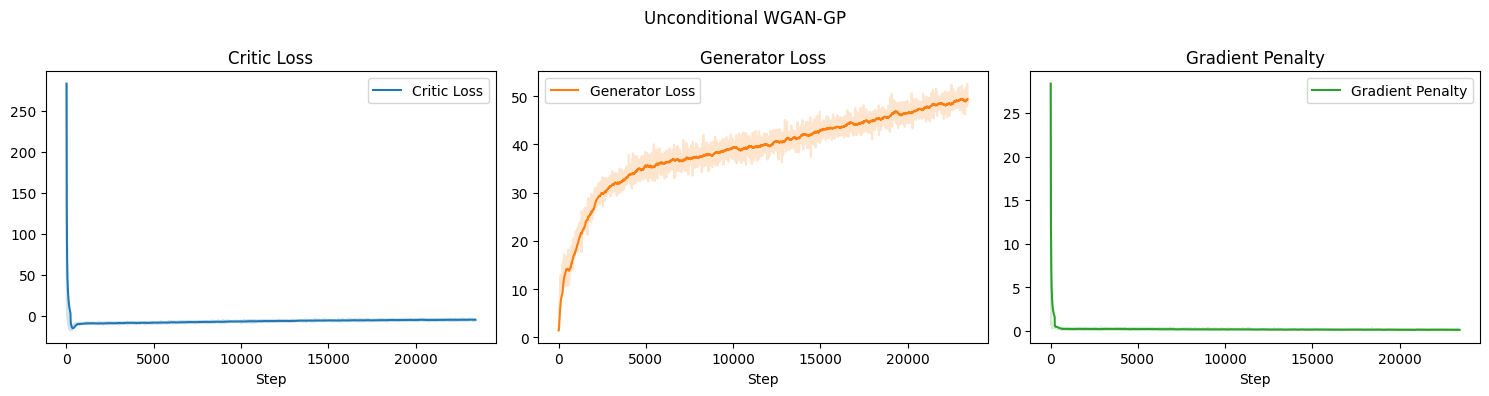

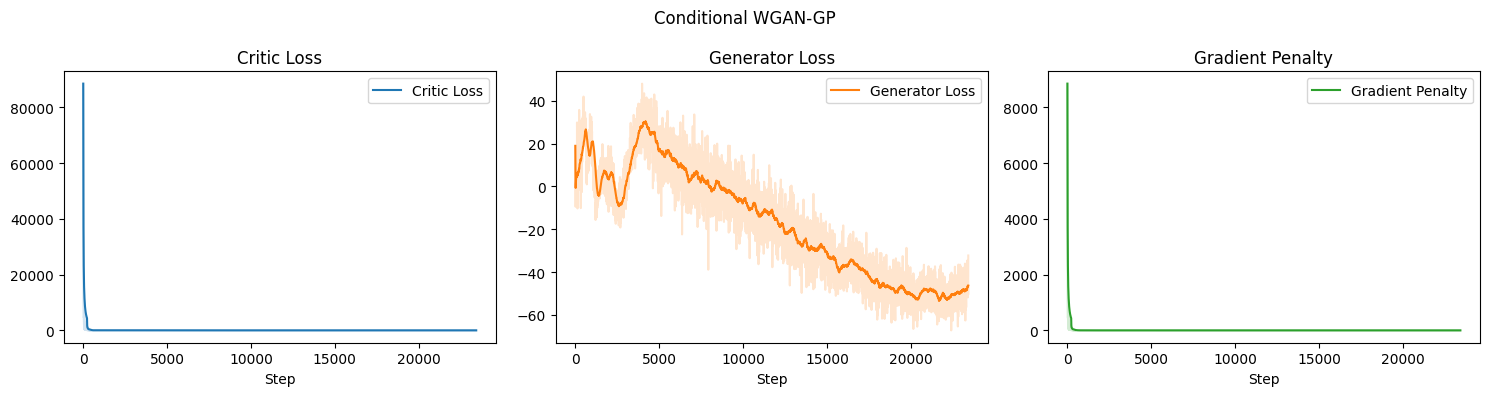

In [15]:
def plot_training(log_path, title):
    df = pd.read_csv(log_path)
    w = max(1, len(df) // 100)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title)
    for ax, col, color, lbl in [
        (axes[0], 'd_loss', 'tab:blue',   'Critic Loss'),
        (axes[1], 'g_loss', 'tab:orange', 'Generator Loss'),
        (axes[2], 'gp',     'tab:green',  'Gradient Penalty'),
    ]:
        ax.plot(df['step'], df[col], alpha=0.2, color=color)
        ax.plot(df['step'], df[col].rolling(w, min_periods=1).mean(),
                color=color, label=lbl)
        ax.set_title(lbl)
        ax.set_xlabel('Step')
        ax.legend()
    plt.tight_layout()
    plt.savefig(log_path.replace('.csv', '_curves.png'), dpi=100)
    plt.show()


plot_training('uncond_log.csv', 'Unconditional WGAN-GP')
plot_training('cond_log.csv', 'Conditional WGAN-GP')

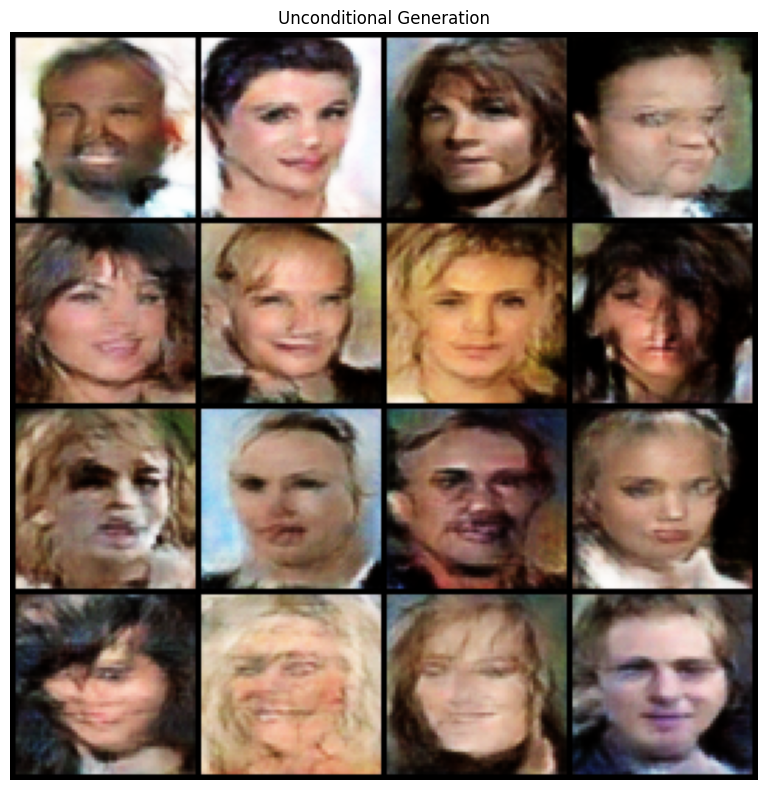

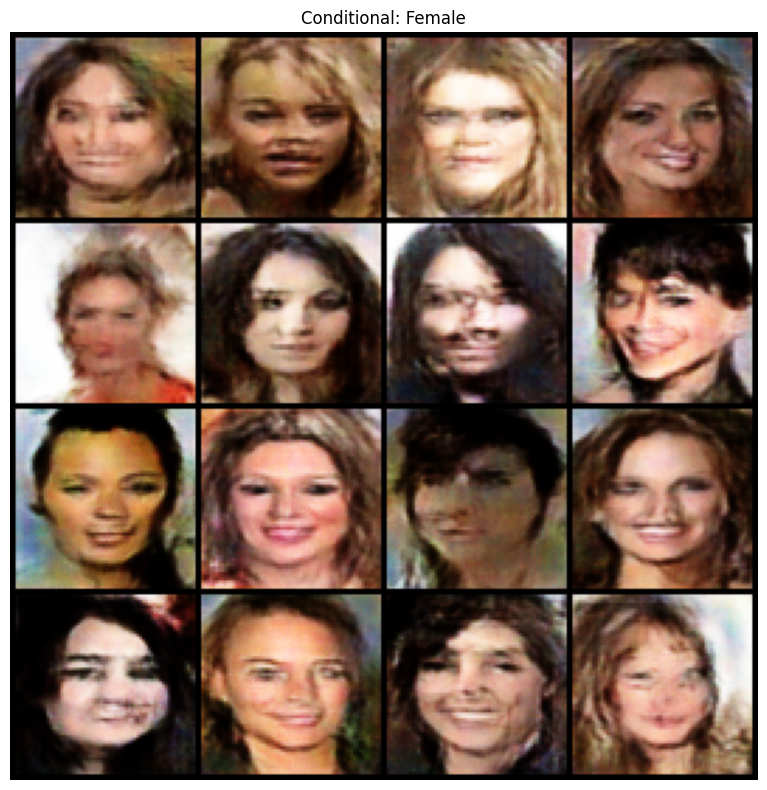

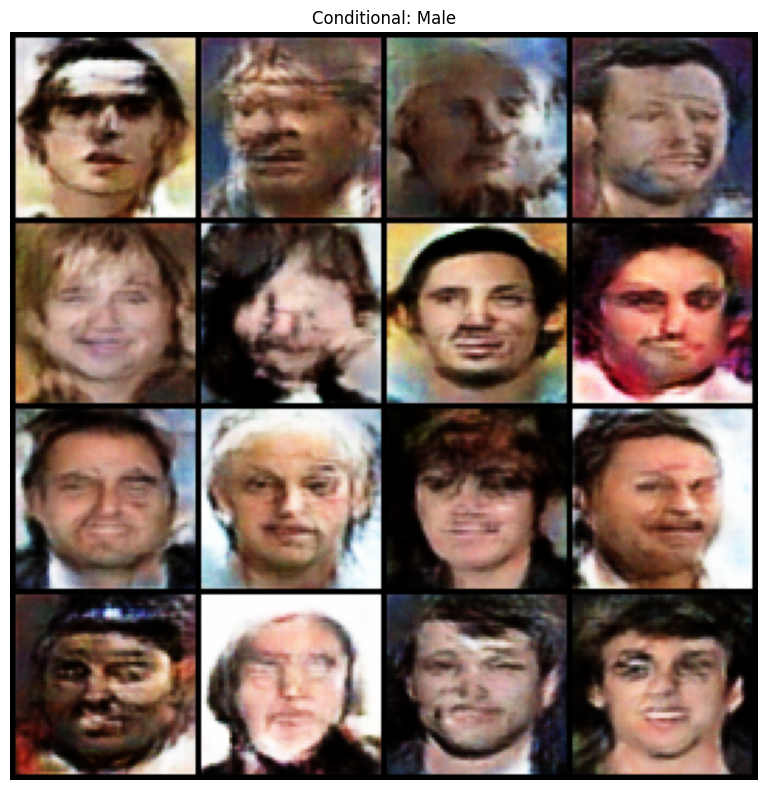

In [16]:
def show_grid(gen, device, n=16, nrow=4, conditional=False, label=None, title=''):
    gen.eval()
    with torch.no_grad():
        z = torch.randn(n, LATENT_DIM, device=device)
        if conditional:
            lbl = torch.full((n,), label, dtype=torch.long, device=device)
            imgs = gen(z, lbl)
        else:
            imgs = gen(z)
    grid = make_grid((imgs.cpu() * 0.5 + 0.5).clamp(0, 1), nrow=nrow, padding=2)
    plt.figure(figsize=(nrow * 2, (n // nrow) * 2))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    gen.train()


show_grid(gen_u, DEVICE, title='Unconditional Generation')
show_grid(gen_c, DEVICE, conditional=True, label=0, title='Conditional: Female')
show_grid(gen_c, DEVICE, conditional=True, label=1, title='Conditional: Male')